# The Hohokam Pattern — Notebook 02: Analysis

**Phase 4 of the weekly publishing project.** Unlike Notebook 01, this notebook is meant to run end-to-end without errors — every number that appears in the technical report or the article must trace to a specific cell here.

Sections:
1. Setup and reprojection
2. Canal-proximity features per tract
3. Univariate exploration of the new features
4. K-Means clustering with PCA visualization
5. Inferential A/B: frequentist + Bayesian dual track
6. Bootstrap stability checks
7. Save outputs for the technical report

Working hypothesis: canal proximity correlates with lower UHI index in Phoenix proper. The analysis will adjudicate.

In [1]:
# Standard imports
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=UserWarning)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Paths
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RAW = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed'
FIGURES = ROOT / 'figures' / 'drafts'
FIGURES.mkdir(parents=True, exist_ok=True)

# Coordinate reference systems
CRS_GEO = 'EPSG:4326'      # WGS84 lat/lon — what raw data uses
CRS_PROJ = 'EPSG:2223'     # NAD83 / Arizona Central, US survey feet
                            # 1 mile = 5,280 ft; 1/4 mile = 1,320 ft

# Random seed for stochastic methods (K-Means, bootstrap, MCMC)
SEED = 42
np.random.seed(SEED)

print(f'Project root:   {ROOT}')
print(f'Geographic CRS: {CRS_GEO}')
print(f'Projected CRS:  {CRS_PROJ} (NAD83 / Arizona Central, ft)')
print(f'Random seed:    {SEED}')

Project root:   /Users/seanjayasekera/Documents/Data Science Projects/Hohokam Pattern
Geographic CRS: EPSG:4326
Projected CRS:  EPSG:2223 (NAD83 / Arizona Central, ft)
Random seed:    42


In [2]:
# Load the working tract dataframe produced by Notebook 01
# (Maricopa tracts joined to Climate Central UHI)
tracts = gpd.read_file(PROCESSED / 'tracts_working.gpkg')
print(f'All Maricopa tracts loaded:        {len(tracts):,}')

# Phoenix-proper scope: keep only tracts with UHI data
phx = tracts[tracts['uhi_index_f'].notna()].copy()
print(f'Phoenix-proper tracts (with UHI):  {len(phx):,}')

# Load canals
canals = gpd.read_file(RAW / 'nhd_canals_phoenix_metro.geojson')
print(f'Canal features loaded:             {len(canals):,}')

# Reproject both to NAD83 / Arizona Central (feet)
phx_proj = phx.to_crs(CRS_PROJ)
canals_proj = canals.to_crs(CRS_PROJ)
print(f'\nReprojected to {CRS_PROJ}')
print(f'Phoenix tracts CRS: {phx_proj.crs.name}')
print(f'Canals CRS:         {canals_proj.crs.name}')

# Sanity-check the extent in projected coordinates
xmin, ymin, xmax, ymax = phx_proj.total_bounds
print(f'\nPhoenix tracts extent (ft):')
print(f'  X (E-W): {xmin:>13,.0f} to {xmax:>13,.0f}  (width  {(xmax-xmin)/5280:,.1f} mi)')
print(f'  Y (N-S): {ymin:>13,.0f} to {ymax:>13,.0f}  (height {(ymax-ymin)/5280:,.1f} mi)')

All Maricopa tracts loaded:        1,009
Phoenix-proper tracts (with UHI):  673
Canal features loaded:             1,475

Reprojected to EPSG:2223
Phoenix tracts CRS: NAD83 / Arizona Central (ft)
Canals CRS:         NAD83 / Arizona Central (ft)

Phoenix tracts extent (ft):
  X (E-W):       448,556 to       967,375  (width  98.3 mi)
  Y (N-S):       801,997 to     1,109,003  (height 58.1 mi)


In [3]:
# For each tract, find the nearest canal segment
# sjoin_nearest uses a spatial index so this is efficient
nearest = gpd.sjoin_nearest(
    phx_proj[['GEOID', 'geometry']],
    canals_proj[['gnis_name', 'lengthkm', 'fcode', 'geometry']],
    how='left',
    distance_col='nearest_canal_ft'
)

# Deduplicate — sjoin_nearest returns multiple rows per tract if there are ties
nearest = nearest.drop_duplicates(subset='GEOID', keep='first')

# Rename canal-name column for clarity
nearest = nearest.rename(columns={'gnis_name': 'nearest_canal_name'})

# Distributional summary
print(f'Tracts: {len(nearest)}')
print(f'\nDistance to nearest canal (ft):')
print(nearest['nearest_canal_ft'].describe().round(0).to_string())
print(f'\nDistance to nearest canal (mi):')
print((nearest['nearest_canal_ft']/5280).describe().round(2).to_string())

# Threshold counts — candidate cutoffs for "canal-adjacent" definition
through_tract = (nearest['nearest_canal_ft'] < 1).sum()
within_quarter = (nearest['nearest_canal_ft'] < 1320).sum()
within_half = (nearest['nearest_canal_ft'] < 2640).sum()
within_one = (nearest['nearest_canal_ft'] < 5280).sum()
n = len(nearest)
print(f'\nCanal passes through tract: {through_tract:>4,} ({100*through_tract/n:5.1f}%)')
print(f'Within 1/4 mile of canal:   {within_quarter:>4,} ({100*within_quarter/n:5.1f}%)')
print(f'Within 1/2 mile of canal:   {within_half:>4,} ({100*within_half/n:5.1f}%)')
print(f'Within 1 mile of canal:     {within_one:>4,} ({100*within_one/n:5.1f}%)')

Tracts: 673

Distance to nearest canal (ft):
count      673.0
mean      2525.0
std       6215.0
min          0.0
25%          0.0
50%          0.0
75%       2303.0
max      45896.0

Distance to nearest canal (mi):
count    673.00
mean       0.48
std        1.18
min        0.00
25%        0.00
50%        0.00
75%        0.44
max        8.69

Canal passes through tract:  381 ( 56.6%)
Within 1/4 mile of canal:    482 ( 71.6%)
Within 1/2 mile of canal:    518 ( 77.0%)
Within 1 mile of canal:      567 ( 84.2%)


In [4]:
# Overlay canals with tracts: clip each canal segment to each tract it passes through
intersections = gpd.overlay(
    canals_proj,
    phx_proj[['GEOID', 'geometry']],
    how='intersection',
    keep_geom_type=False
)
intersections['intersection_ft'] = intersections.geometry.length

# Aggregate: total canal length per tract
canal_in_tract = (
    intersections.groupby('GEOID')['intersection_ft']
    .sum()
    .rename('canal_ft_in_tract')
    .reset_index()
)

# Build the growing tract-level features dataframe
# Start from phx_proj so UHI and other tract-level attributes are preserved
prox = (
    phx_proj[['GEOID', 'uhi_index_f', 'uhi_index_c']]
    .merge(nearest[['GEOID', 'nearest_canal_ft', 'nearest_canal_name']], on='GEOID', how='left')
    .merge(canal_in_tract, on='GEOID', how='left')
)
prox['canal_ft_in_tract'] = prox['canal_ft_in_tract'].fillna(0)

# Distribution
n_with_canal = (prox['canal_ft_in_tract'] > 0).sum()
print(f'Tracts with any canal segment inside: {n_with_canal:,} ({100*n_with_canal/len(prox):.1f}%)')
print(f'\nCanal length within tract (ft):')
print(prox['canal_ft_in_tract'].describe().round(0).to_string())
print(f'Canal length within tract (mi):')
print((prox['canal_ft_in_tract']/5280).describe().round(2).to_string())

# Top tracts by canal mileage
top10 = (
    prox.nlargest(10, 'canal_ft_in_tract')
        .assign(canal_mi=lambda d: d['canal_ft_in_tract']/5280)
        [['GEOID', 'canal_mi', 'nearest_canal_name', 'uhi_index_f']]
)
print(f'\nTop 10 tracts by canal mileage inside:')
print(top10.round(2).to_string(index=False))

Tracts with any canal segment inside: 379 (56.3%)

Canal length within tract (ft):
count       673.0
mean       5691.0
std       16949.0
min           0.0
25%           0.0
50%        1585.0
75%        6006.0
max      304771.0
Canal length within tract (mi):
count    673.00
mean       1.08
std        3.21
min        0.00
25%        0.00
50%        0.30
75%        1.14
max       57.72

Top 10 tracts by canal mileage inside:
      GEOID  canal_mi nearest_canal_name  uhi_index_f
04013941000     57.72                NaN         6.00
04013941300     44.48                NaN         6.00
04013092720     13.14                NaN         5.88
04013112510     12.04                NaN         7.53
04013112512     11.99                NaN         8.81
04013040538     10.55                NaN         5.39
04013112514      9.98                NaN         5.88
04013116611      9.58                NaN         6.11
04013610800      9.00                NaN         5.88
04013082208      7.78  Saint John

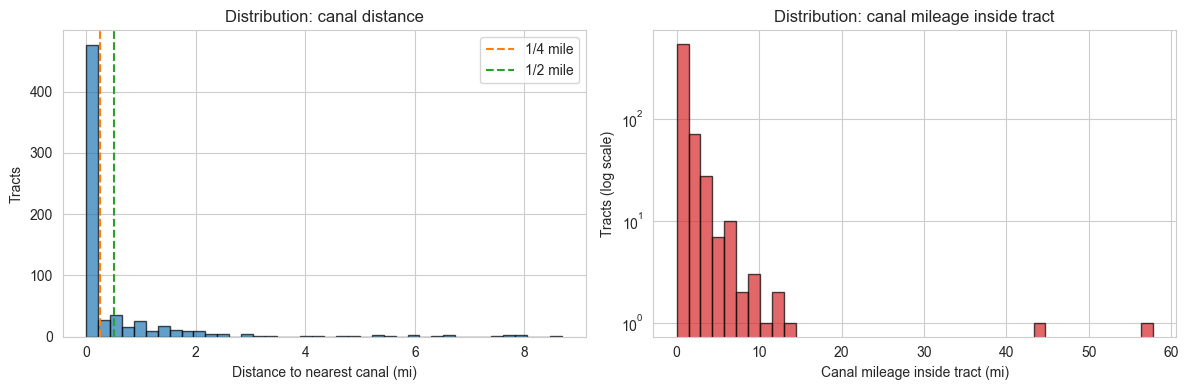

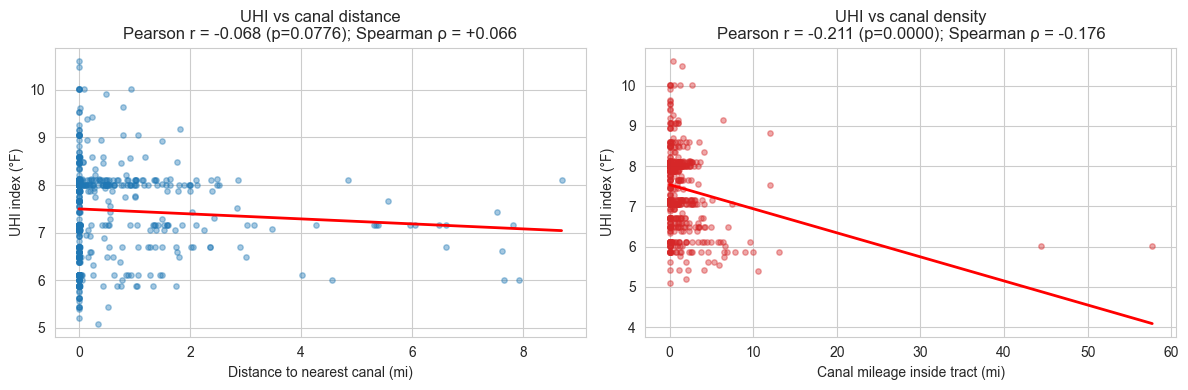

Correlations with UHI (n = 673 tracts):
  Distance to nearest canal:  Pearson r = -0.068 (p = 0.0776),  Spearman ρ = +0.066
  Canal mileage inside tract: Pearson r = -0.211 (p = 0.0000),  Spearman ρ = -0.176

Sign convention:
  Distance ↔ UHI: POSITIVE r → farther canal = hotter (supports cooling thesis)
                  NEGATIVE r → closer canal = hotter (canals concentrated in urban core)
  Density  ↔ UHI: NEGATIVE r → more canal = cooler (supports cooling thesis)
                  POSITIVE r → more canal = hotter (urban infrastructure effect)


In [5]:
from scipy import stats

# Convert to miles for plotting/interpretation
prox['nearest_canal_mi'] = prox['nearest_canal_ft'] / 5280
prox['canal_mi_in_tract'] = prox['canal_ft_in_tract'] / 5280

# Univariate distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(prox['nearest_canal_mi'], bins=40, edgecolor='black', alpha=0.7)
axes[0].axvline(0.25, color='C1', linestyle='--', label='1/4 mile')
axes[0].axvline(0.5, color='C2', linestyle='--', label='1/2 mile')
axes[0].set_xlabel('Distance to nearest canal (mi)')
axes[0].set_ylabel('Tracts'); axes[0].set_title('Distribution: canal distance')
axes[0].legend()

axes[1].hist(prox['canal_mi_in_tract'], bins=40, edgecolor='black', alpha=0.7, color='C3')
axes[1].set_xlabel('Canal mileage inside tract (mi)')
axes[1].set_ylabel('Tracts (log scale)'); axes[1].set_title('Distribution: canal mileage inside tract')
axes[1].set_yscale('log')
plt.tight_layout(); plt.show()

# Bivariate: each proximity feature vs UHI
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

mask1 = prox['nearest_canal_mi'].notna() & prox['uhi_index_f'].notna()
x1, y1 = prox.loc[mask1, 'nearest_canal_mi'], prox.loc[mask1, 'uhi_index_f']
slope1, intercept1, r1, p1, _ = stats.linregress(x1, y1)
rho1, _ = stats.spearmanr(x1, y1)
axes[0].scatter(x1, y1, alpha=0.4, s=15)
xl = np.linspace(0, x1.max(), 100)
axes[0].plot(xl, intercept1 + slope1*xl, color='red', linewidth=2)
axes[0].set_xlabel('Distance to nearest canal (mi)'); axes[0].set_ylabel('UHI index (°F)')
axes[0].set_title(f'UHI vs canal distance\nPearson r = {r1:+.3f} (p={p1:.4f}); Spearman ρ = {rho1:+.3f}')

mask2 = prox['canal_mi_in_tract'].notna() & prox['uhi_index_f'].notna()
x2, y2 = prox.loc[mask2, 'canal_mi_in_tract'], prox.loc[mask2, 'uhi_index_f']
slope2, intercept2, r2, p2, _ = stats.linregress(x2, y2)
rho2, _ = stats.spearmanr(x2, y2)
axes[1].scatter(x2, y2, alpha=0.4, s=15, color='C3')
xl = np.linspace(0, x2.max(), 100)
axes[1].plot(xl, intercept2 + slope2*xl, color='red', linewidth=2)
axes[1].set_xlabel('Canal mileage inside tract (mi)'); axes[1].set_ylabel('UHI index (°F)')
axes[1].set_title(f'UHI vs canal density\nPearson r = {r2:+.3f} (p={p2:.4f}); Spearman ρ = {rho2:+.3f}')
plt.tight_layout(); plt.show()

print(f'Correlations with UHI (n = {mask1.sum()} tracts):')
print(f'  Distance to nearest canal:  Pearson r = {r1:+.3f} (p = {p1:.4f}),  Spearman ρ = {rho1:+.3f}')
print(f'  Canal mileage inside tract: Pearson r = {r2:+.3f} (p = {p2:.4f}),  Spearman ρ = {rho2:+.3f}')
print()
print('Sign convention:')
print('  Distance ↔ UHI: POSITIVE r → farther canal = hotter (supports cooling thesis)')
print('                  NEGATIVE r → closer canal = hotter (canals concentrated in urban core)')
print('  Density  ↔ UHI: NEGATIVE r → more canal = cooler (supports cooling thesis)')
print('                  POSITIVE r → more canal = hotter (urban infrastructure effect)')

In [6]:
# What are the high-canal-mileage outliers?
outliers = prox.nlargest(5, 'canal_mi_in_tract')[
    ['GEOID', 'canal_mi_in_tract', 'nearest_canal_name', 'uhi_index_f']
]

# Add tract area
phx_area = phx_proj.copy()
phx_area['area_mi2'] = phx_area.geometry.area / (5280**2)
outliers = outliers.merge(
    phx_area[['GEOID', 'area_mi2', 'NAMELSAD']], on='GEOID', how='left'
)
outliers['canal_per_mi2'] = outliers['canal_mi_in_tract'] / outliers['area_mi2']
print('Top 5 tracts by canal mileage inside:')
print(outliers.round(2).to_string(index=False))
print()

# Add area to the full prox dataframe (we'll need it later anyway)
prox = prox.merge(phx_area[['GEOID', 'area_mi2']], on='GEOID', how='left')

# Re-run correlations after dropping extreme outliers
filtered = prox[prox['canal_mi_in_tract'] < 20].copy()
n_dropped = len(prox) - len(filtered)
print(f'Dropping {n_dropped} tracts with > 20 mi of canal inside.')
print(f'Remaining: {len(filtered)} tracts.\n')

mask = filtered['nearest_canal_mi'].notna() & filtered['uhi_index_f'].notna()
r1, p1 = stats.pearsonr(filtered.loc[mask, 'nearest_canal_mi'], filtered.loc[mask, 'uhi_index_f'])
rho1, _ = stats.spearmanr(filtered.loc[mask, 'nearest_canal_mi'], filtered.loc[mask, 'uhi_index_f'])

mask = filtered['canal_mi_in_tract'].notna() & filtered['uhi_index_f'].notna()
r2, p2 = stats.pearsonr(filtered.loc[mask, 'canal_mi_in_tract'], filtered.loc[mask, 'uhi_index_f'])
rho2, _ = stats.spearmanr(filtered.loc[mask, 'canal_mi_in_tract'], filtered.loc[mask, 'uhi_index_f'])

print('Correlations with UHI, outliers removed:')
print(f'  Distance: Pearson r = {r1:+.3f} (p = {p1:.4f}),  Spearman ρ = {rho1:+.3f}')
print(f'  Density:  Pearson r = {r2:+.3f} (p = {p2:.4f}),  Spearman ρ = {rho2:+.3f}')
print()
print('Original (with outliers):')
print('  Distance: r = -0.068 (p=0.0776),  ρ = +0.066')
print('  Density:  r = -0.211 (p=0.0000),  ρ = -0.176')

Top 5 tracts by canal mileage inside:
      GEOID  canal_mi_in_tract nearest_canal_name  uhi_index_f  area_mi2             NAMELSAD  canal_per_mi2
04013941000              57.72                NaN         6.00    114.87    Census Tract 9410           0.50
04013941300              44.48                NaN         6.00     84.99    Census Tract 9413           0.52
04013092720              13.14                NaN         5.88      8.92  Census Tract 927.20           1.47
04013112510              12.04                NaN         7.53      3.97 Census Tract 1125.10           3.03
04013112512              11.99                NaN         8.81      4.47 Census Tract 1125.12           2.68

Dropping 2 tracts with > 20 mi of canal inside.
Remaining: 671 tracts.

Correlations with UHI, outliers removed:
  Distance: Pearson r = -0.070 (p = 0.0687),  Spearman ρ = +0.062
  Density:  Pearson r = -0.266 (p = 0.0000),  Spearman ρ = -0.169

Original (with outliers):
  Distance: r = -0.068 (p=0.0776), 

Threshold (median canal density): 0.265 mi/mi²

Group sizes:
canal_dense
False    336
True     335

UHI summary by group:
                    count   mean    std  median
Low canal density     336  7.499  0.910   7.875
High canal density    335  7.455  0.904   7.875


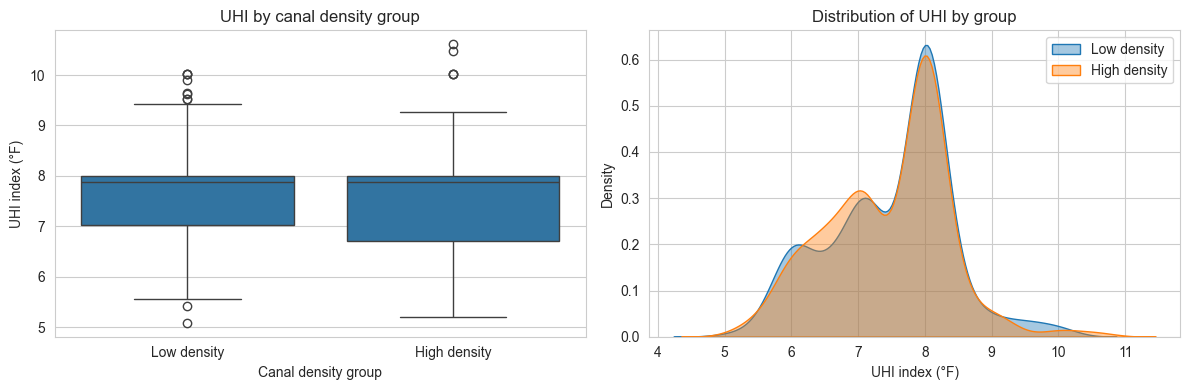

In [7]:
# Define the A/B binary using canal density (controls for tract size)
filtered['canal_per_mi2'] = filtered['canal_mi_in_tract'] / filtered['area_mi2']

# Use median as the threshold for a balanced split
median_density = filtered['canal_per_mi2'].median()
filtered['canal_dense'] = filtered['canal_per_mi2'] > median_density

# Group sizes and summary statistics
print(f'Threshold (median canal density): {median_density:.3f} mi/mi²')
print(f'\nGroup sizes:')
print(filtered['canal_dense'].value_counts().to_string())
print()

summary = filtered.groupby('canal_dense')['uhi_index_f'].agg(['count', 'mean', 'std', 'median'])
summary.index = ['Low canal density', 'High canal density']
print('UHI summary by group:')
print(summary.round(3).to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=filtered, x='canal_dense', y='uhi_index_f', ax=axes[0])
axes[0].set_xticklabels(['Low density', 'High density'])
axes[0].set_xlabel('Canal density group')
axes[0].set_ylabel('UHI index (°F)')
axes[0].set_title('UHI by canal density group')

sns.kdeplot(data=filtered[~filtered['canal_dense']], x='uhi_index_f',
            label='Low density', ax=axes[1], fill=True, alpha=0.4)
sns.kdeplot(data=filtered[filtered['canal_dense']], x='uhi_index_f',
            label='High density', ax=axes[1], fill=True, alpha=0.4)
axes[1].set_xlabel('UHI index (°F)')
axes[1].set_title('Distribution of UHI by group')
axes[1].legend()
plt.tight_layout()
plt.show()

In [8]:
# Frequentist A/B test on canal density groups
group_low = filtered.loc[~filtered['canal_dense'], 'uhi_index_f']
group_high = filtered.loc[filtered['canal_dense'], 'uhi_index_f']

# Welch's t-test (does not assume equal variances — safer than Student's t)
t_stat, p_val = stats.ttest_ind(group_high, group_low, equal_var=False)

# Difference in means
diff = group_high.mean() - group_low.mean()

# 95% CI on the difference (Welch–Satterthwaite df)
n_h, n_l = len(group_high), len(group_low)
v_h, v_l = group_high.var(ddof=1), group_low.var(ddof=1)
se_diff = np.sqrt(v_h/n_h + v_l/n_l)
df_welch = (v_h/n_h + v_l/n_l)**2 / ((v_h/n_h)**2/(n_h-1) + (v_l/n_l)**2/(n_l-1))
t_crit = stats.t.ppf(0.975, df_welch)
ci_low = diff - t_crit * se_diff
ci_high = diff + t_crit * se_diff

# Cohen's d (pooled SD effect size)
pooled_sd = np.sqrt(((n_h - 1)*v_h + (n_l - 1)*v_l) / (n_h + n_l - 2))
cohen_d = diff / pooled_sd

print("Frequentist test: Welch's two-sample t-test")
print("─" * 55)
print("  H₀: mean UHI equal in high- and low-density groups")
print("  H₁: means differ")
print()
print(f'  Mean UHI, low canal density:   {group_low.mean():.3f} °F  (n = {n_l})')
print(f'  Mean UHI, high canal density:  {group_high.mean():.3f} °F  (n = {n_h})')
print(f'  Difference (high − low):        {diff:+.3f} °F')
print()
print(f'  95% CI on difference:           [{ci_low:+.3f}, {ci_high:+.3f}] °F')
print(f'  Welch t-statistic:              {t_stat:+.3f}')
print(f'  Welch–Satterthwaite df:         {df_welch:.1f}')
print(f'  p-value:                        {p_val:.5f}')
print(f"  Cohen's d:                      {cohen_d:+.3f}")

Frequentist test: Welch's two-sample t-test
───────────────────────────────────────────────────────
  H₀: mean UHI equal in high- and low-density groups
  H₁: means differ

  Mean UHI, low canal density:   7.499 °F  (n = 336)
  Mean UHI, high canal density:  7.455 °F  (n = 335)
  Difference (high − low):        -0.044 °F

  95% CI on difference:           [-0.182, +0.093] °F
  Welch t-statistic:              -0.630
  Welch–Satterthwaite df:         669.0
  p-value:                        0.52921
  Cohen's d:                      -0.049


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_low, mu_high, sigma_low, sigma_high]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


Bayesian posterior summary (95% credible interval):
           mean      sd eti95_lb eti95_ub  ess_bulk  ess_tail r_hat mcse_mean  mcse_sd
mu_low      7.5  0.0501      7.4      7.6      9423      5845  1.00   0.00052  0.00037
mu_high   7.455  0.0497      7.4      7.6      9107      5677  1.00   0.00052  0.00037
diff     -0.045   0.071    -0.19    0.094      9001      5505  1.00   0.00075  0.00054
cohen_d  -0.049   0.078    -0.21      0.1      9056      5598  1.00   0.00082   0.0006

Posterior P(diff < 0 °F):    0.7361   (high density cooler at all)
Posterior P(diff < −0.5 °F): 0.0000   (high density at least half a degree cooler)
Posterior P(diff < −1.0 °F): 0.0000   (high density at least one full degree cooler)


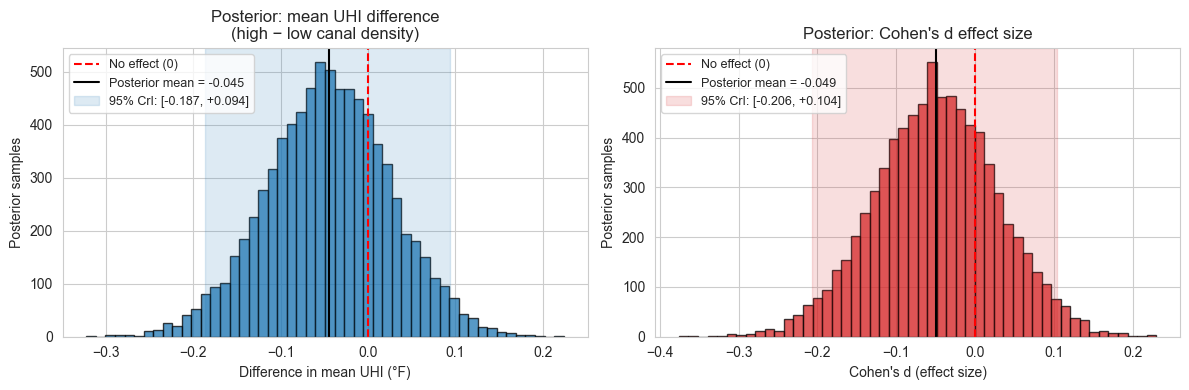

In [9]:
import pymc as pm
import arviz as az

# Prepare data
y_low = group_low.values
y_high = group_high.values

with pm.Model() as model:
    # Priors on group means
    mu_low  = pm.Normal('mu_low',  mu=7.0, sigma=3.0)
    mu_high = pm.Normal('mu_high', mu=7.0, sigma=3.0)
    
    # Priors on group standard deviations
    sigma_low  = pm.HalfNormal('sigma_low',  sigma=3.0)
    sigma_high = pm.HalfNormal('sigma_high', sigma=3.0)
    
    # Likelihood
    pm.Normal('obs_low',  mu=mu_low,  sigma=sigma_low,  observed=y_low)
    pm.Normal('obs_high', mu=mu_high, sigma=sigma_high, observed=y_high)
    
    # Derived quantities
    diff = pm.Deterministic('diff', mu_high - mu_low)
    pooled = pm.Deterministic('pooled_sd', pm.math.sqrt((sigma_low**2 + sigma_high**2) / 2))
    cohen_d = pm.Deterministic('cohen_d', diff / pooled)
    
    # Sample
    trace = pm.sample(2000, tune=1000, target_accept=0.95,
                      random_seed=SEED, progressbar=True, chains=4)

# Summary table
summary = az.summary(trace, var_names=['mu_low', 'mu_high', 'diff', 'cohen_d'], ci_prob=0.95)
print('Bayesian posterior summary (95% credible interval):')
print(summary.round(3).to_string())
print()

# Extract posterior samples for downstream use
diff_samples = trace.posterior['diff'].values.flatten()
cohen_d_samples = trace.posterior['cohen_d'].values.flatten()

# Posterior probabilities of meaningful effects
prob_negative = (diff_samples < 0).mean()
prob_half_deg = (diff_samples < -0.5).mean()
prob_one_deg  = (diff_samples < -1.0).mean()
print(f"Posterior P(diff < 0 °F):    {prob_negative:.4f}   (high density cooler at all)")
print(f"Posterior P(diff < −0.5 °F): {prob_half_deg:.4f}   (high density at least half a degree cooler)")
print(f"Posterior P(diff < −1.0 °F): {prob_one_deg:.4f}   (high density at least one full degree cooler)")

# Visualize posteriors directly in matplotlib (avoids ArviZ plot API churn)
diff_lo, diff_hi = np.percentile(diff_samples, [2.5, 97.5])
d_lo, d_hi = np.percentile(cohen_d_samples, [2.5, 97.5])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: posterior of difference
axes[0].hist(diff_samples, bins=50, alpha=0.75, color='C0', edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='No effect (0)')
axes[0].axvline(diff_samples.mean(), color='black', linestyle='-', linewidth=1.5,
                label=f'Posterior mean = {diff_samples.mean():+.3f}')
axes[0].axvspan(diff_lo, diff_hi, alpha=0.15, color='C0',
                label=f'95% CrI: [{diff_lo:+.3f}, {diff_hi:+.3f}]')
axes[0].set_xlabel('Difference in mean UHI (°F)')
axes[0].set_ylabel('Posterior samples')
axes[0].set_title('Posterior: mean UHI difference\n(high − low canal density)')
axes[0].legend(loc='upper left', fontsize=9)

# Right: posterior of Cohen's d
axes[1].hist(cohen_d_samples, bins=50, alpha=0.75, color='C3', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='No effect (0)')
axes[1].axvline(cohen_d_samples.mean(), color='black', linestyle='-', linewidth=1.5,
                label=f'Posterior mean = {cohen_d_samples.mean():+.3f}')
axes[1].axvspan(d_lo, d_hi, alpha=0.15, color='C3',
                label=f'95% CrI: [{d_lo:+.3f}, {d_hi:+.3f}]')
axes[1].set_xlabel("Cohen's d (effect size)")
axes[1].set_ylabel('Posterior samples')
axes[1].set_title("Posterior: Cohen's d effect size")
axes[1].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

Canal density quartile thresholds:
  25th percentile: 0.000 mi/mi²
  75th percentile: 1.292 mi/mi²

Bottom quartile: 294 tracts
Top quartile:    168 tracts

UHI summary by extreme quartile:
  Bottom Q (low canal density) : mean=7.573, sd=0.870, n=294
  Top Q (high canal density)   : mean=7.456, sd=0.875, n=168


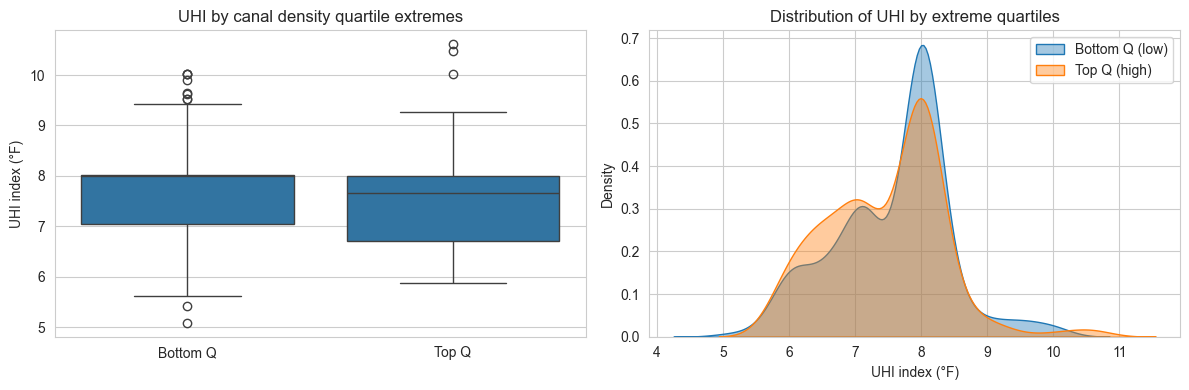


Welch's t-test on extremes (top Q − bottom Q):
  Difference: -0.117 °F
  95% CI:     [-0.283, +0.050] °F
  t = -1.381,  p = 0.1683
  Cohen's d:  -0.134


In [10]:
# Compare top vs bottom quartile of canal density (instead of median split)
q25 = filtered['canal_per_mi2'].quantile(0.25)
q75 = filtered['canal_per_mi2'].quantile(0.75)
print(f'Canal density quartile thresholds:')
print(f'  25th percentile: {q25:.3f} mi/mi²')
print(f'  75th percentile: {q75:.3f} mi/mi²\n')

bottom_q = filtered[filtered['canal_per_mi2'] <= q25].copy()
top_q = filtered[filtered['canal_per_mi2'] >= q75].copy()
print(f'Bottom quartile: {len(bottom_q)} tracts')
print(f'Top quartile:    {len(top_q)} tracts\n')

print('UHI summary by extreme quartile:')
for label, df in [('Bottom Q (low canal density) ', bottom_q),
                  ('Top Q (high canal density)   ', top_q)]:
    print(f'  {label}: mean={df["uhi_index_f"].mean():.3f}, sd={df["uhi_index_f"].std():.3f}, n={len(df)}')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
combined = pd.concat([
    bottom_q.assign(group='Bottom Q'),
    top_q.assign(group='Top Q')
])
sns.boxplot(data=combined, x='group', y='uhi_index_f', ax=axes[0])
axes[0].set_xlabel('')
axes[0].set_ylabel('UHI index (°F)')
axes[0].set_title('UHI by canal density quartile extremes')

sns.kdeplot(data=bottom_q, x='uhi_index_f', label='Bottom Q (low)', ax=axes[1], fill=True, alpha=0.4)
sns.kdeplot(data=top_q, x='uhi_index_f', label='Top Q (high)', ax=axes[1], fill=True, alpha=0.4)
axes[1].set_xlabel('UHI index (°F)')
axes[1].set_title('Distribution of UHI by extreme quartiles')
axes[1].legend()
plt.tight_layout()
plt.show()

# Welch's t-test on extremes
t_stat, p_val = stats.ttest_ind(top_q['uhi_index_f'], bottom_q['uhi_index_f'], equal_var=False)
diff = top_q['uhi_index_f'].mean() - bottom_q['uhi_index_f'].mean()
n_t, n_b = len(top_q), len(bottom_q)
v_t, v_b = top_q['uhi_index_f'].var(ddof=1), bottom_q['uhi_index_f'].var(ddof=1)
se_diff = np.sqrt(v_t/n_t + v_b/n_b)
df_welch = (v_t/n_t + v_b/n_b)**2 / ((v_t/n_t)**2/(n_t-1) + (v_b/n_b)**2/(n_b-1))
t_crit = stats.t.ppf(0.975, df_welch)
ci_low = diff - t_crit * se_diff
ci_high = diff + t_crit * se_diff
pooled_sd = np.sqrt(((n_t-1)*v_t + (n_b-1)*v_b) / (n_t + n_b - 2))
cohen_d = diff / pooled_sd

print(f"\nWelch's t-test on extremes (top Q − bottom Q):")
print(f"  Difference: {diff:+.3f} °F")
print(f"  95% CI:     [{ci_low:+.3f}, {ci_high:+.3f}] °F")
print(f"  t = {t_stat:+.3f},  p = {p_val:.4f}")
print(f"  Cohen's d:  {cohen_d:+.3f}")

In [11]:
import urllib.request
import json

# Load API key from outside the project
key_path = Path.home() / '.census_api_key'
with open(key_path) as f:
    CENSUS_API_KEY = f.read().strip()
print(f'Census API key loaded ({len(CENSUS_API_KEY)} chars)')

# ACS variables we want (2023 5-year estimates)
variables_to_request = [
    'NAME',
    'B01003_001E',  # Total population
    'B19013_001E',  # Median household income
    'B25077_001E',  # Median home value
    'B25064_001E',  # Median gross rent
    'B02001_002E',  # White alone
    'B02001_003E',  # Black alone
    'B03003_003E',  # Hispanic or Latino
    'B25035_001E',  # Median year structure built
    'B25003_002E',  # Owner-occupied housing units
    'B25003_001E',  # Total occupied housing units
]

# Request all tracts in Maricopa County (state 04, county 013)
var_str = ','.join(variables_to_request)
url = (f"https://api.census.gov/data/2023/acs/acs5?get={var_str}"
       f"&for=tract:*&in=state:04%20county:013&key={CENSUS_API_KEY}")

with urllib.request.urlopen(url) as r:
    raw = json.load(r)

# First row is header, rest are data
acs_df = pd.DataFrame(raw[1:], columns=raw[0])
print(f'Received {len(acs_df)} tract records')

# Build standard 11-digit GEOID
acs_df['GEOID'] = acs_df['state'] + acs_df['county'] + acs_df['tract']

# Convert numeric columns; Census uses big negative numbers for suppressed/unavailable
numeric_cols = [v for v in variables_to_request if v != 'NAME']
for col in numeric_cols:
    acs_df[col] = pd.to_numeric(acs_df[col], errors='coerce')
    acs_df.loc[acs_df[col] < 0, col] = np.nan

# Compute derived percentages
acs_df['pct_white']    = acs_df['B02001_002E'] / acs_df['B01003_001E'] * 100
acs_df['pct_black']    = acs_df['B02001_003E'] / acs_df['B01003_001E'] * 100
acs_df['pct_hispanic'] = acs_df['B03003_003E'] / acs_df['B01003_001E'] * 100
acs_df['pct_owner_occupied'] = acs_df['B25003_002E'] / acs_df['B25003_001E'] * 100

# Rename code columns to human-readable names
acs_df = acs_df.rename(columns={
    'B01003_001E': 'pop_total',
    'B19013_001E': 'median_hh_income',
    'B25077_001E': 'median_home_value',
    'B25064_001E': 'median_rent',
    'B25035_001E': 'median_year_built',
})

# Save the raw pull for the audit trail
acs_df.to_csv(RAW / 'acs_2023_5yr_maricopa_tracts.csv', index=False)
print(f'Saved to {RAW / "acs_2023_5yr_maricopa_tracts.csv"}')

# Merge into prox and filtered (the working analytical dataframes)
keep_cols = ['GEOID', 'pop_total', 'median_hh_income', 'median_home_value',
             'median_rent', 'median_year_built', 'pct_white', 'pct_black',
             'pct_hispanic', 'pct_owner_occupied']

prox     = prox.merge(acs_df[keep_cols], on='GEOID', how='left')
filtered = filtered.merge(acs_df[keep_cols], on='GEOID', how='left')

# Validation
print(f'\nMerged ACS into prox ({len(prox)} tracts) and filtered ({len(filtered)} tracts)')
print(f'\nMissing-value check on filtered set:')
for col in ['median_hh_income', 'median_home_value', 'median_year_built', 'pct_white']:
    n_missing = filtered[col].isna().sum()
    print(f'  {col:25s}  {n_missing:>4} missing ({100*n_missing/len(filtered):5.1f}%)')

print(f'\nKey ACS variables — Phoenix-proper tracts:')
print(filtered[['median_hh_income', 'median_home_value', 'median_year_built',
                'pct_white']].describe().round(1).to_string())

Census API key loaded (40 chars)
Received 1009 tract records
Saved to /Users/seanjayasekera/Documents/Data Science Projects/Hohokam Pattern/data/raw/acs_2023_5yr_maricopa_tracts.csv

Merged ACS into prox (673 tracts) and filtered (671 tracts)

Missing-value check on filtered set:
  median_hh_income             13 missing (  1.9%)
  median_home_value            31 missing (  4.6%)
  median_year_built            25 missing (  3.7%)
  pct_white                     7 missing (  1.0%)

Key ACS variables — Phoenix-proper tracts:
       median_hh_income  median_home_value  median_year_built  pct_white
count             658.0              640.0              646.0      664.0
mean            85727.0           417679.5             1984.9       59.7
std             34769.6           224368.3               14.2       20.6
min             23232.0            10400.0             1942.0        0.0
25%             60492.8           284750.0             1975.0       42.2
50%             80229.0          

Sample sizes:
  Tracts with UHI + income:     658
  Tracts with UHI + home value: 640


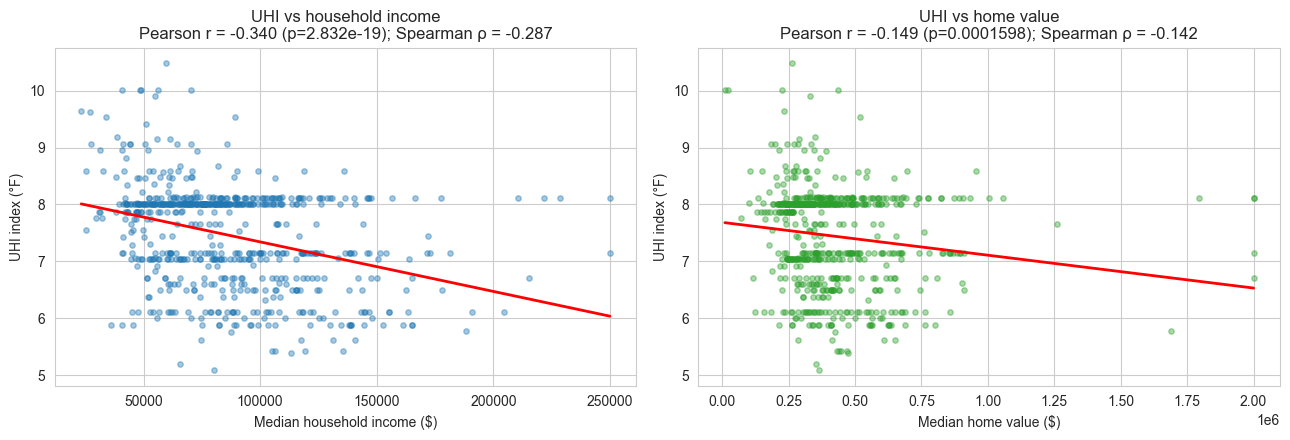


Correlation comparison (Phoenix-proper tracts):
  Canal density vs UHI:     r = -0.266   (from Cell 7, after outlier removal)
  Median income vs UHI:     r = -0.340
  Median home value vs UHI: r = -0.149

Variance explained:
  Canal density:  r² = 0.071  (7.1% of UHI variance)
  Income:         r² = 0.116  (11.6% of UHI variance)
  Home value:     r² = 0.022  (2.2% of UHI variance)

Income effect is 1.3× stronger than canal density (by |r|).


In [12]:
# Correlation: income/wealth vs UHI
# Mirror the structure of the canal analysis for clean side-by-side comparison

income_mask = filtered['median_hh_income'].notna() & filtered['uhi_index_f'].notna()
home_mask   = filtered['median_home_value'].notna() & filtered['uhi_index_f'].notna()

print(f'Sample sizes:')
print(f'  Tracts with UHI + income:     {income_mask.sum():,}')
print(f'  Tracts with UHI + home value: {home_mask.sum():,}')

# Compute correlations
x_inc = filtered.loc[income_mask, 'median_hh_income']
y_inc = filtered.loc[income_mask, 'uhi_index_f']
r_inc, p_inc = stats.pearsonr(x_inc, y_inc)
rho_inc, _   = stats.spearmanr(x_inc, y_inc)

x_val = filtered.loc[home_mask, 'median_home_value']
y_val = filtered.loc[home_mask, 'uhi_index_f']
r_val, p_val = stats.pearsonr(x_val, y_val)
rho_val, _   = stats.spearmanr(x_val, y_val)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(x_inc, y_inc, alpha=0.4, s=15)
m_inc, b_inc, *_ = stats.linregress(x_inc, y_inc)
xl = np.linspace(x_inc.min(), x_inc.max(), 100)
axes[0].plot(xl, m_inc*xl + b_inc, color='red', linewidth=2)
axes[0].set_xlabel('Median household income ($)')
axes[0].set_ylabel('UHI index (°F)')
axes[0].set_title(f'UHI vs household income\nPearson r = {r_inc:+.3f} (p={p_inc:.4g}); Spearman ρ = {rho_inc:+.3f}')

axes[1].scatter(x_val, y_val, alpha=0.4, s=15, color='C2')
m_val, b_val, *_ = stats.linregress(x_val, y_val)
xl = np.linspace(x_val.min(), x_val.max(), 100)
axes[1].plot(xl, m_val*xl + b_val, color='red', linewidth=2)
axes[1].set_xlabel('Median home value ($)')
axes[1].set_ylabel('UHI index (°F)')
axes[1].set_title(f'UHI vs home value\nPearson r = {r_val:+.3f} (p={p_val:.4g}); Spearman ρ = {rho_val:+.3f}')

plt.tight_layout()
plt.show()

# Side-by-side magnitude comparison with the canal finding
print(f'\nCorrelation comparison (Phoenix-proper tracts):')
print(f'  Canal density vs UHI:     r = -0.266   (from Cell 7, after outlier removal)')
print(f'  Median income vs UHI:     r = {r_inc:+.3f}')
print(f'  Median home value vs UHI: r = {r_val:+.3f}')
print(f'\nVariance explained:')
print(f'  Canal density:  r² = {0.266**2:.3f}  ({0.266**2*100:.1f}% of UHI variance)')
print(f'  Income:         r² = {r_inc**2:.3f}  ({r_inc**2*100:.1f}% of UHI variance)')
print(f'  Home value:     r² = {r_val**2:.3f}  ({r_val**2*100:.1f}% of UHI variance)')

if abs(r_inc) > 0.266:
    print(f'\nIncome effect is {abs(r_inc)/0.266:.1f}× stronger than canal density (by |r|).')

Predictor strength ranking (Phoenix-proper tracts):
          variable  pearson_r  spearman_rho  r_squared  pct_variance   n  p_value
 median_year_built    -0.4853       -0.4606     0.2356       23.5555 646   0.0000
pct_owner_occupied    -0.3836       -0.3245     0.1472       14.7171 660   0.0000
  median_hh_income    -0.3401       -0.2874     0.1156       11.5634 658   0.0000
       median_rent    -0.3268       -0.2980     0.1068       10.6776 633   0.0000
 canal_mi_in_tract    -0.2663       -0.1691     0.0709        7.0893 671   0.0000
 median_home_value    -0.1487       -0.1422     0.0221        2.2110 640   0.0002
      pct_hispanic     0.1365        0.0884     0.0186        1.8638 664   0.0004
         pct_white    -0.1221       -0.0613     0.0149        1.4899 664   0.0016
          area_mi2    -0.1199       -0.3918     0.0144        1.4367 671   0.0019
  nearest_canal_mi    -0.0703        0.0621     0.0049        0.4946 671   0.0687
         pct_black     0.0226       -0.0280   

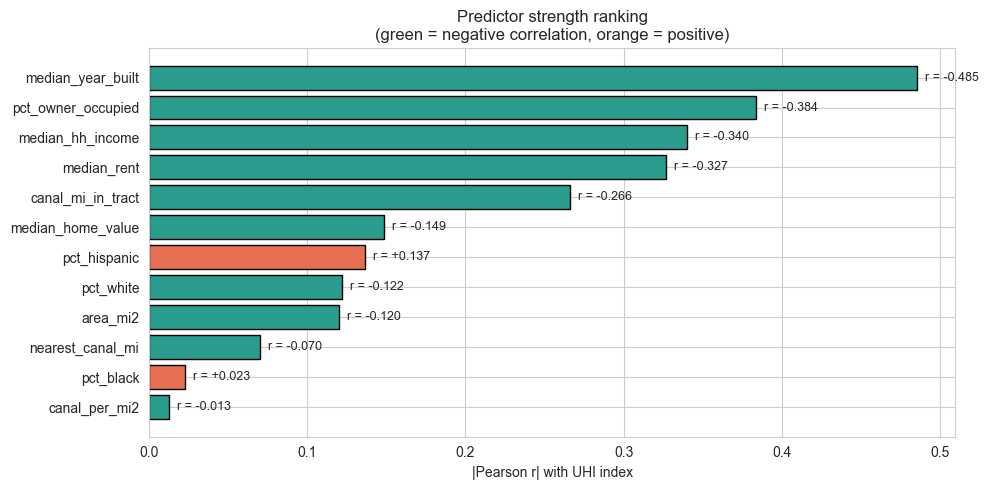

In [13]:
# Which variables correlate most strongly with UHI?
# Goal: pick the strongest predictor for the deeper dual-track analysis

candidate_vars = [
    'canal_per_mi2', 'nearest_canal_mi', 'canal_mi_in_tract',
    'median_hh_income', 'median_home_value', 'median_rent', 'median_year_built',
    'pct_white', 'pct_black', 'pct_hispanic', 'pct_owner_occupied',
    'area_mi2',
]

results = []
for var in candidate_vars:
    if var not in filtered.columns:
        continue
    mask = filtered[var].notna() & filtered['uhi_index_f'].notna()
    if mask.sum() < 50:
        continue
    r, p = stats.pearsonr(filtered.loc[mask, var], filtered.loc[mask, 'uhi_index_f'])
    rho, _ = stats.spearmanr(filtered.loc[mask, var], filtered.loc[mask, 'uhi_index_f'])
    results.append({
        'variable': var,
        'pearson_r': r,
        'spearman_rho': rho,
        'r_squared': r**2,
        'pct_variance': r**2 * 100,
        'n': mask.sum(),
        'p_value': p,
    })

corr_df = pd.DataFrame(results).sort_values('r_squared', ascending=False)
print('Predictor strength ranking (Phoenix-proper tracts):')
print(corr_df.round(4).to_string(index=False))

# Visualize as horizontal bar chart of |r|, color-coded by sign
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = corr_df.copy()
plot_df['abs_r'] = plot_df['pearson_r'].abs()
plot_df = plot_df.sort_values('abs_r', ascending=True)
colors = ['#2a9d8f' if r < 0 else '#e76f51' for r in plot_df['pearson_r']]
ax.barh(plot_df['variable'], plot_df['abs_r'], color=colors, edgecolor='black')
ax.set_xlabel('|Pearson r| with UHI index')
ax.set_title('Predictor strength ranking\n(green = negative correlation, orange = positive)')
for i, (val, r) in enumerate(zip(plot_df['abs_r'], plot_df['pearson_r'])):
    ax.text(val + 0.005, i, f'r = {r:+.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

Median year built threshold: 1985
Group sizes:
newer_tract
False    333
True     313

UHI summary by year-built group:
                               count   mean    std  median
Older tracts (built ≤ median)    333  7.814  0.641   8.001
Newer tracts (built > median)    313  7.116  0.972   7.047



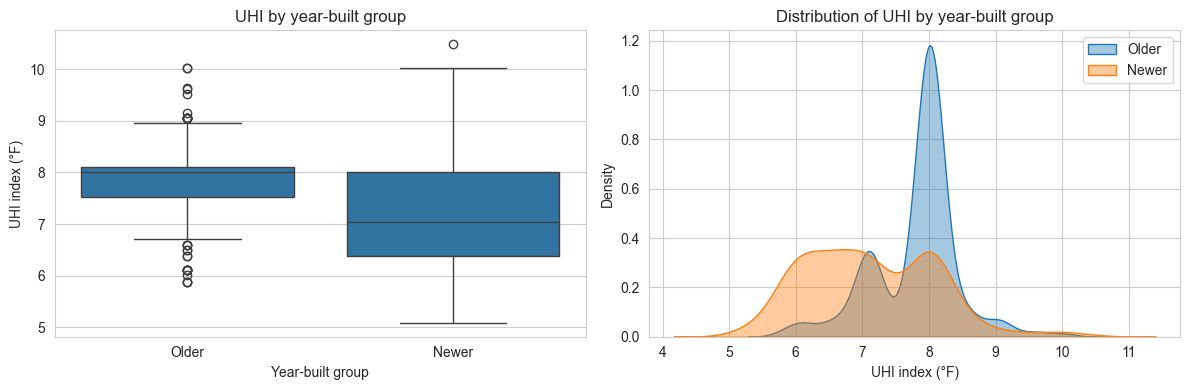

Welch's t-test (newer − older):
  Difference: -0.698 °F
  95% CI:     [-0.826, -0.570] °F
  t = -10.709,  p = 2.218e-24
  Cohen's d:  -0.853


In [14]:
# Define A/B on median year built (median split)
yb_filtered = filtered[filtered['median_year_built'].notna()].copy()
median_yb = yb_filtered['median_year_built'].median()
yb_filtered['newer_tract'] = yb_filtered['median_year_built'] > median_yb

print(f'Median year built threshold: {median_yb:.0f}')
print(f'Group sizes:')
print(yb_filtered['newer_tract'].value_counts().to_string())
print()

summary = yb_filtered.groupby('newer_tract')['uhi_index_f'].agg(['count', 'mean', 'std', 'median'])
summary.index = ['Older tracts (built ≤ median)', 'Newer tracts (built > median)']
print('UHI summary by year-built group:')
print(summary.round(3).to_string())
print()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=yb_filtered, x='newer_tract', y='uhi_index_f', ax=axes[0])
axes[0].set_xticklabels(['Older', 'Newer'])
axes[0].set_xlabel('Year-built group')
axes[0].set_ylabel('UHI index (°F)')
axes[0].set_title('UHI by year-built group')

sns.kdeplot(data=yb_filtered[~yb_filtered['newer_tract']], x='uhi_index_f',
            label='Older', ax=axes[1], fill=True, alpha=0.4)
sns.kdeplot(data=yb_filtered[yb_filtered['newer_tract']], x='uhi_index_f',
            label='Newer', ax=axes[1], fill=True, alpha=0.4)
axes[1].set_xlabel('UHI index (°F)')
axes[1].set_title('Distribution of UHI by year-built group')
axes[1].legend()
plt.tight_layout()
plt.show()

# Frequentist test
older = yb_filtered.loc[~yb_filtered['newer_tract'], 'uhi_index_f']
newer = yb_filtered.loc[ yb_filtered['newer_tract'], 'uhi_index_f']

t_stat, p_val = stats.ttest_ind(newer, older, equal_var=False)
diff = newer.mean() - older.mean()
n_n, n_o = len(newer), len(older)
v_n, v_o = newer.var(ddof=1), older.var(ddof=1)
se_diff = np.sqrt(v_n/n_n + v_o/n_o)
df_welch = (v_n/n_n + v_o/n_o)**2 / ((v_n/n_n)**2/(n_n-1) + (v_o/n_o)**2/(n_o-1))
t_crit = stats.t.ppf(0.975, df_welch)
ci_low = diff - t_crit * se_diff
ci_high = diff + t_crit * se_diff
pooled_sd = np.sqrt(((n_n-1)*v_n + (n_o-1)*v_o) / (n_n + n_o - 2))
cohen_d = diff / pooled_sd

print(f"Welch's t-test (newer − older):")
print(f"  Difference: {diff:+.3f} °F")
print(f"  95% CI:     [{ci_low:+.3f}, {ci_high:+.3f}] °F")
print(f"  t = {t_stat:+.3f},  p = {p_val:.4g}")
print(f"  Cohen's d:  {cohen_d:+.3f}")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_older, mu_newer, sigma_older, sigma_newer]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


Bayesian posterior summary (year-built A/B):
            mean      sd eti95_lb eti95_ub  ess_bulk  ess_tail r_hat mcse_mean  mcse_sd
mu_older  7.8143  0.0351      7.7      7.9      9548      5509  1.00   0.00036  0.00026
mu_newer   7.117  0.0547        7      7.2      9569      5667  1.00   0.00056   0.0004
diff      -0.697   0.066    -0.83    -0.57      9362      5353  1.00   0.00068   0.0005
cohen_d   -0.845   0.084       -1    -0.68      9365      5662  1.00   0.00087  0.00063

Posterior P(newer cooler than older): 1.0000
Posterior P(diff < −0.5 °F):          0.9980
Posterior P(diff < −1.0 °F):          0.0000


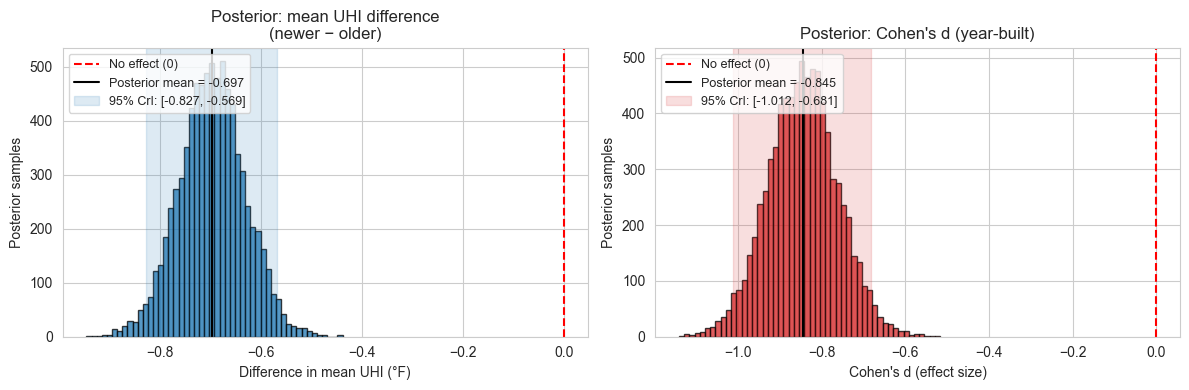

In [15]:
# Bayesian dual-track on year built (parallel to Cell 10's canal analysis)

y_older = older.values  # from Cell 15
y_newer = newer.values

with pm.Model() as model_yb:
    mu_older = pm.Normal('mu_older', mu=7.0, sigma=3.0)
    mu_newer = pm.Normal('mu_newer', mu=7.0, sigma=3.0)
    
    sigma_older = pm.HalfNormal('sigma_older', sigma=3.0)
    sigma_newer = pm.HalfNormal('sigma_newer', sigma=3.0)
    
    pm.Normal('obs_older', mu=mu_older, sigma=sigma_older, observed=y_older)
    pm.Normal('obs_newer', mu=mu_newer, sigma=sigma_newer, observed=y_newer)
    
    diff_yb = pm.Deterministic('diff', mu_newer - mu_older)
    pooled_yb = pm.Deterministic('pooled_sd', pm.math.sqrt((sigma_older**2 + sigma_newer**2)/2))
    cohen_d_yb = pm.Deterministic('cohen_d', diff_yb / pooled_yb)
    
    trace_yb = pm.sample(2000, tune=1000, target_accept=0.95,
                          random_seed=SEED, progressbar=True, chains=4)

# Summary
summary_yb = az.summary(trace_yb, var_names=['mu_older', 'mu_newer', 'diff', 'cohen_d'], ci_prob=0.95)
print('Bayesian posterior summary (year-built A/B):')
print(summary_yb.round(3).to_string())
print()

# Posterior samples for downstream use
diff_samples_yb = trace_yb.posterior['diff'].values.flatten()
cohen_d_samples_yb = trace_yb.posterior['cohen_d'].values.flatten()

# Probabilities of meaningful effects
print(f"Posterior P(newer cooler than older): {(diff_samples_yb < 0).mean():.4f}")
print(f"Posterior P(diff < −0.5 °F):          {(diff_samples_yb < -0.5).mean():.4f}")
print(f"Posterior P(diff < −1.0 °F):          {(diff_samples_yb < -1.0).mean():.4f}")

# Visualize
diff_lo, diff_hi = np.percentile(diff_samples_yb, [2.5, 97.5])
d_lo, d_hi = np.percentile(cohen_d_samples_yb, [2.5, 97.5])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(diff_samples_yb, bins=50, alpha=0.75, color='C0', edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='No effect (0)')
axes[0].axvline(diff_samples_yb.mean(), color='black', linestyle='-', linewidth=1.5,
                label=f'Posterior mean = {diff_samples_yb.mean():+.3f}')
axes[0].axvspan(diff_lo, diff_hi, alpha=0.15, color='C0',
                label=f'95% CrI: [{diff_lo:+.3f}, {diff_hi:+.3f}]')
axes[0].set_xlabel('Difference in mean UHI (°F)')
axes[0].set_ylabel('Posterior samples')
axes[0].set_title('Posterior: mean UHI difference\n(newer − older)')
axes[0].legend(loc='upper left', fontsize=9)

axes[1].hist(cohen_d_samples_yb, bins=50, alpha=0.75, color='C3', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='No effect (0)')
axes[1].axvline(cohen_d_samples_yb.mean(), color='black', linestyle='-', linewidth=1.5,
                label=f'Posterior mean = {cohen_d_samples_yb.mean():+.3f}')
axes[1].axvspan(d_lo, d_hi, alpha=0.15, color='C3',
                label=f'95% CrI: [{d_lo:+.3f}, {d_hi:+.3f}]')
axes[1].set_xlabel("Cohen's d (effect size)")
axes[1].set_ylabel('Posterior samples')
axes[1].set_title("Posterior: Cohen's d (year-built)")
axes[1].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

In [16]:
from sklearn.preprocessing import StandardScaler

# Features that describe what kind of neighborhood a tract is
# UHI is deliberately NOT included — it's the outcome we'll characterize clusters by
cluster_features = [
    'median_year_built',
    'median_hh_income',
    'pct_owner_occupied',
    'pct_hispanic',
    'canal_per_mi2',
    'area_mi2',
]

# Drop rows with any missing values on the clustering features for a fair comparison
cluster_df = filtered[['GEOID', 'uhi_index_f'] + cluster_features].dropna().copy()
n_dropped = len(filtered) - len(cluster_df)
print(f'Tracts available for clustering: {len(cluster_df)}')
print(f'Dropped for missing values:       {n_dropped} ({100*n_dropped/len(filtered):.1f}%)')

# Standardize (z-score) so K-means treats all features on equal footing
scaler = StandardScaler()
X = scaler.fit_transform(cluster_df[cluster_features])

# Sanity check: post-scaling mean should be 0 and std should be 1 for every feature
print('\nFeature standardization check (post z-score):')
check = pd.DataFrame(X, columns=cluster_features).agg(['mean', 'std']).round(3)
print(check.to_string())

# Store standardized columns alongside the originals for later use
for i, f in enumerate(cluster_features):
    cluster_df[f + '_z'] = X[:, i]

# Preview
print(f'\ncluster_df shape: {cluster_df.shape}')
print(f'First 3 rows of standardized features:')
print(cluster_df[[f + '_z' for f in cluster_features]].head(3).round(3).to_string())

Tracts available for clustering: 646
Dropped for missing values:       25 (3.7%)

Feature standardization check (post z-score):
      median_year_built  median_hh_income  pct_owner_occupied  pct_hispanic  canal_per_mi2  area_mi2
mean             -0.000             0.000               0.000         0.000         -0.000    -0.000
std               1.001             1.001               1.001         1.001          1.001     1.001

cluster_df shape: (646, 14)
First 3 rows of standardized features:
   median_year_built_z  median_hh_income_z  pct_owner_occupied_z  pct_hispanic_z  canal_per_mi2_z  area_mi2_z
0                0.148              -0.847                -1.667           1.086           -0.075      -0.052
1               -0.628               0.967                 1.406          -1.201            0.384      -0.063
3               -0.557              -1.070                -1.478           0.603            3.511      -0.076


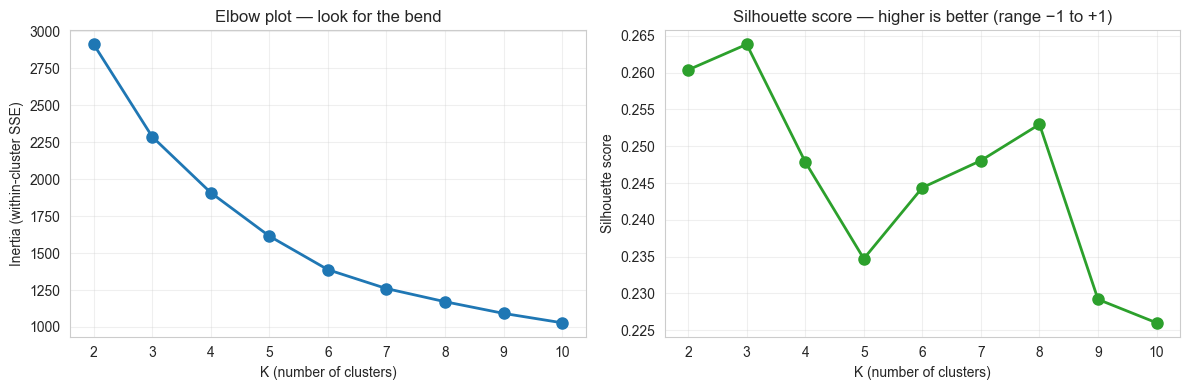

K-means diagnostics by K:
   K     Inertia    Silhouette
   2      2912.3         0.260
   3      2286.8         0.264
   4      1908.6         0.248
   5      1614.8         0.235
   6      1387.8         0.244
   7      1259.9         0.248
   8      1171.1         0.253
   9      1092.1         0.229
  10      1028.4         0.226


In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Try K from 2 to 10 and record two diagnostics for each
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

# Plot both diagnostics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, 'o-', linewidth=2, markersize=8)
axes[0].set_xlabel('K (number of clusters)')
axes[0].set_ylabel('Inertia (within-cluster SSE)')
axes[0].set_title('Elbow plot — look for the bend')
axes[0].set_xticks(list(k_range))
axes[0].grid(alpha=0.3)

axes[1].plot(k_range, silhouettes, 'o-', linewidth=2, markersize=8, color='C2')
axes[1].set_xlabel('K (number of clusters)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score — higher is better (range −1 to +1)')
axes[1].set_xticks(list(k_range))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print the diagnostics as a table
print('K-means diagnostics by K:')
print(f'{"K":>4}  {"Inertia":>10}  {"Silhouette":>12}')
for k, inertia, sil in zip(k_range, inertias, silhouettes):
    print(f'{k:>4}  {inertia:>10.1f}  {sil:>12.3f}')

In [18]:
# Diagnose and remove the area outlier — one tract is >1000 sq mi (federal/wilderness),
# which K-means treated as its own degenerate cluster
area_threshold = 50  # square miles; no normal urban tract approaches this
outliers_area = cluster_df[cluster_df['area_mi2'] > area_threshold]
print(f'Removing {len(outliers_area)} tracts with area > {area_threshold} mi²:')
print(outliers_area[['GEOID', 'area_mi2', 'median_year_built', 'uhi_index_f']].to_string(index=False))

cluster_df = cluster_df[cluster_df['area_mi2'] <= area_threshold].copy()
print(f'\nRemaining tracts for clustering: {len(cluster_df)}')

# Re-standardize after removal (cluster_df changed, so we re-fit the scaler)
scaler = StandardScaler()
X = scaler.fit_transform(cluster_df[cluster_features])

# Re-fit K-means with K=4
K = 4
kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=20)
cluster_df['cluster'] = kmeans.fit_predict(X)

print(f'\nK-means fit with K = {K} (after outlier removal)')
print(f'\nCluster sizes:')
print(cluster_df['cluster'].value_counts().sort_index().to_string())

# Cluster centers in original units
centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=cluster_features
)
centers.insert(0, 'cluster', range(K))
centers.insert(1, 'n', cluster_df['cluster'].value_counts().sort_index().values)

uhi_by_cluster = (
    cluster_df.groupby('cluster')['uhi_index_f']
    .agg(['mean', 'std', 'median'])
    .round(2)
    .rename(columns={'mean': 'uhi_mean', 'std': 'uhi_std', 'median': 'uhi_median'})
)
summary_tbl = centers.merge(uhi_by_cluster, left_on='cluster', right_index=True)

display_tbl = summary_tbl.copy()
display_tbl['median_year_built']   = display_tbl['median_year_built'].round(0).astype(int)
display_tbl['median_hh_income']    = display_tbl['median_hh_income'].round(0).astype(int)
display_tbl['pct_owner_occupied']  = display_tbl['pct_owner_occupied'].round(1)
display_tbl['pct_hispanic']        = display_tbl['pct_hispanic'].round(1)
display_tbl['canal_per_mi2']       = display_tbl['canal_per_mi2'].round(2)
display_tbl['area_mi2']            = display_tbl['area_mi2'].round(1)

print('\nCluster centers (original units) + UHI summary:')
print(display_tbl.to_string(index=False))

# Re-merge cluster labels back into filtered, dropping the old bad assignment first
if 'cluster' in filtered.columns:
    filtered = filtered.drop(columns=['cluster'])
filtered = filtered.merge(cluster_df[['GEOID', 'cluster']], on='GEOID', how='left')

Removing 4 tracts with area > 50 mi²:
      GEOID    area_mi2  median_year_built  uhi_index_f
04013040535   87.413134             2014.0      6.00264
04013610002   87.751828             2006.0      6.00264
04013040539  164.759295             2006.0      5.75064
04013010102 1057.753750             2005.0      5.76864

Remaining tracts for clustering: 642

K-means fit with K = 4 (after outlier removal)

Cluster sizes:
cluster
0    143
1    232
2      7
3    260

Cluster centers (original units) + UHI summary:
 cluster   n  median_year_built  median_hh_income  pct_owner_occupied  pct_hispanic  canal_per_mi2  area_mi2  uhi_mean  uhi_std  uhi_median
       0 143               1990             75952                55.8          47.8           2.18       1.2      7.33     0.86        7.55
       1 232               1975             60616                44.6          49.5           0.35       0.8      7.91     0.74        8.00
       2   7               2003            123113                82

Variance explained:
  PC1: 39.0%
  PC2: 18.5%
  Total in 2D: 57.5%

Feature loadings on the first two PCs:
                      PC1    PC2
median_year_built   0.358  0.483
median_hh_income    0.557  0.008
pct_owner_occupied  0.460 -0.008
pct_hispanic       -0.470  0.252
canal_per_mi2      -0.141  0.819
area_mi2            0.330  0.182


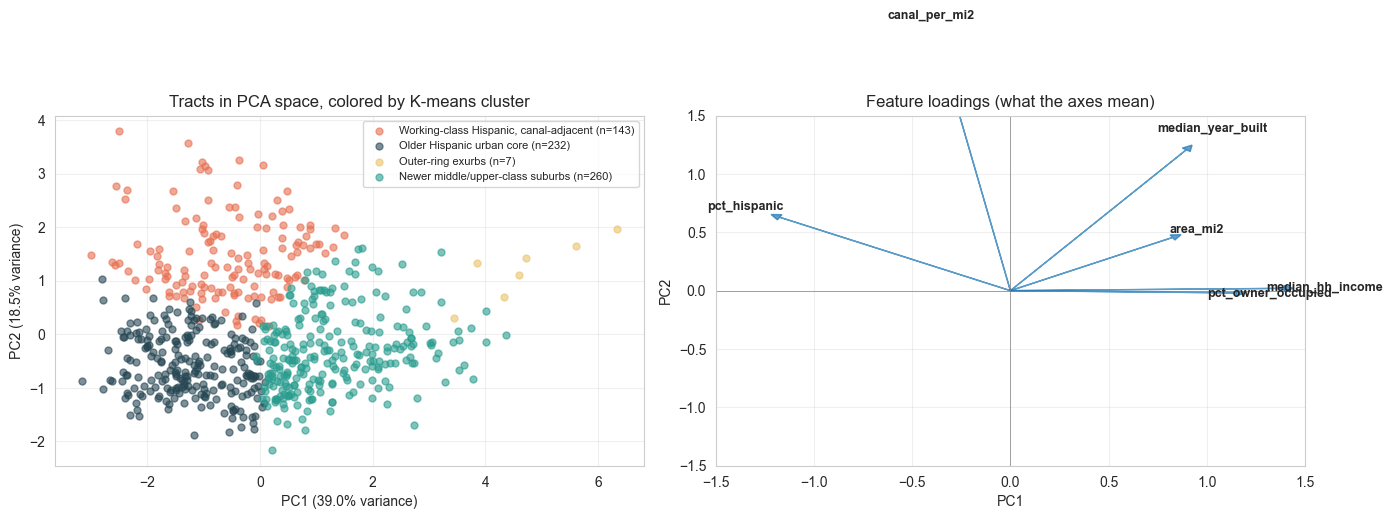

In [19]:
from sklearn.decomposition import PCA

# PCA on the same standardized features used for K-means
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)

cluster_df['pc1'] = pcs[:, 0]
cluster_df['pc2'] = pcs[:, 1]

var_explained = pca.explained_variance_ratio_
print(f'Variance explained:')
print(f'  PC1: {var_explained[0]*100:.1f}%')
print(f'  PC2: {var_explained[1]*100:.1f}%')
print(f'  Total in 2D: {sum(var_explained)*100:.1f}%')

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=cluster_features
)
print(f'\nFeature loadings on the first two PCs:')
print(loadings.round(3).to_string())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Cluster archetype labels for legend
cluster_labels = {
    0: 'Working-class Hispanic, canal-adjacent',
    1: 'Older Hispanic urban core',
    2: 'Outer-ring exurbs',
    3: 'Newer middle/upper-class suburbs',
}
palette = ['#e76f51', '#264653', '#e9c46a', '#2a9d8f']

# Left: PC scatter colored by cluster
for c in range(K):
    sub = cluster_df[cluster_df['cluster'] == c]
    axes[0].scatter(sub['pc1'], sub['pc2'], alpha=0.6, s=25,
                    label=f'{cluster_labels[c]} (n={len(sub)})', color=palette[c])
axes[0].set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% variance)')
axes[0].set_title('Tracts in PCA space, colored by K-means cluster')
axes[0].legend(loc='best', fontsize=8)
axes[0].grid(alpha=0.3)

# Right: feature loadings biplot
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
for i, f in enumerate(cluster_features):
    x_arrow = loadings.iloc[i, 0] * 2.5
    y_arrow = loadings.iloc[i, 1] * 2.5
    axes[1].arrow(0, 0, x_arrow, y_arrow, head_width=0.05, head_length=0.05,
                  fc='C0', ec='C0', alpha=0.7)
    axes[1].text(x_arrow*1.15, y_arrow*1.15, f, ha='center', va='center',
                 fontsize=9, fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Feature loadings (what the axes mean)')
axes[1].set_xlim(-1.5, 1.5)
axes[1].set_ylim(-1.5, 1.5)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/s5/fxncr3_d39j27_97bgrrwg8c0000gn/T/ipykernel_8577/888014999.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


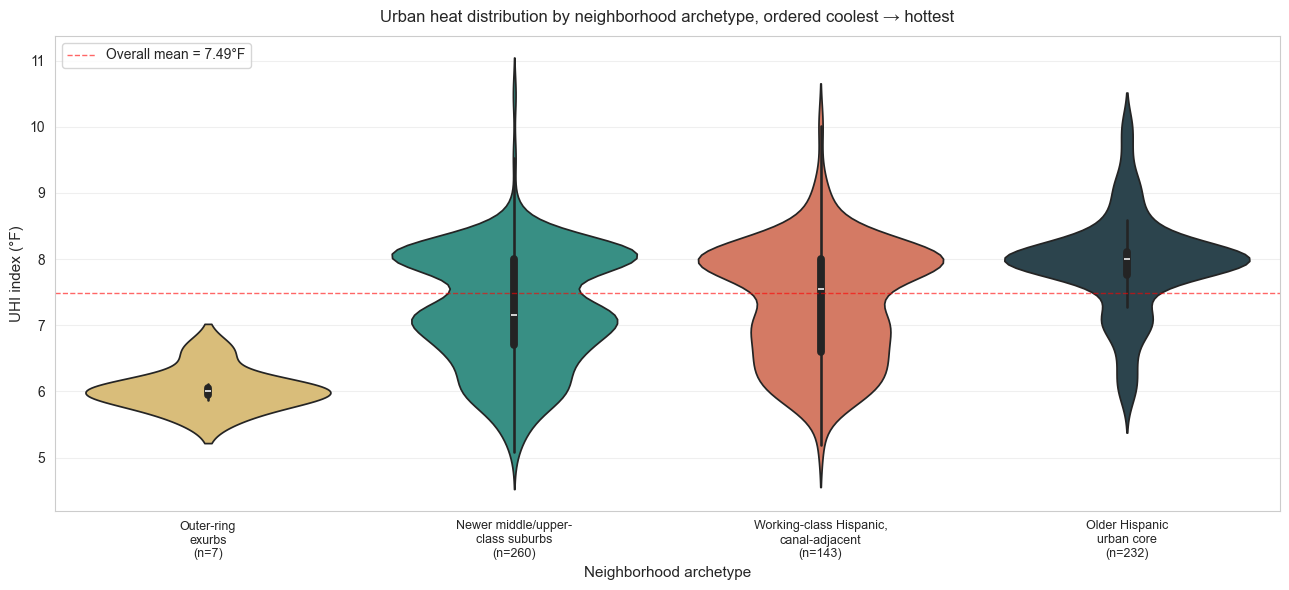


UHI by cluster archetype (sorted coolest → hottest):
Archetype                                     n    Mean  Median    Std
----------------------------------------------------------------------
Outer-ring exurbs                             7    6.03    6.00   0.30
Newer middle/upper- class suburbs           260    7.23    7.15   0.85
Working-class Hispanic, canal-adjacent      143    7.33    7.55   0.86
Older Hispanic urban core                   232    7.91    8.00   0.74


In [20]:
import seaborn as sns

# Order clusters coolest to hottest for narrative arc
order = cluster_df.groupby('cluster')['uhi_index_f'].mean().sort_values().index.tolist()
cluster_df['cluster_ordered'] = pd.Categorical(cluster_df['cluster'], categories=order, ordered=True)

cluster_labels = {
    0: 'Working-class Hispanic,\ncanal-adjacent',
    1: 'Older Hispanic\nurban core',
    2: 'Outer-ring\nexurbs',
    3: 'Newer middle/upper-\nclass suburbs',
}
palette_dict = {0: '#e76f51', 1: '#264653', 2: '#e9c46a', 3: '#2a9d8f'}
palette_ordered = [palette_dict[c] for c in order]

# Violin plot — shows distribution shape + box stats
fig, ax = plt.subplots(figsize=(13, 6))
sns.violinplot(
    data=cluster_df,
    x='cluster_ordered',
    y='uhi_index_f',
    palette=palette_ordered,
    inner='box',
    ax=ax,
)
ax.set_xticklabels(
    [f'{cluster_labels[c]}\n(n={(cluster_df["cluster"]==c).sum()})' for c in order],
    rotation=0, fontsize=9
)
ax.set_xlabel('Neighborhood archetype', fontsize=11)
ax.set_ylabel('UHI index (°F)', fontsize=11)
ax.set_title('Urban heat distribution by neighborhood archetype, ordered coolest → hottest',
             fontsize=12, pad=10)
overall_mean = cluster_df['uhi_index_f'].mean()
ax.axhline(overall_mean, color='red', linestyle='--', linewidth=1, alpha=0.6,
           label=f'Overall mean = {overall_mean:.2f}°F')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Numerical summary table — sorted coolest to hottest
print('\nUHI by cluster archetype (sorted coolest → hottest):')
print(f'{"Archetype":<42s}{"n":>5s}{"Mean":>8s}{"Median":>8s}{"Std":>7s}')
print('-' * 70)
for c in order:
    label_flat = cluster_labels[c].replace('\n', ' ')
    sub = cluster_df[cluster_df['cluster'] == c]
    print(f'{label_flat:<42s}{len(sub):>5d}{sub["uhi_index_f"].mean():>8.2f}'
          f'{sub["uhi_index_f"].median():>8.2f}{sub["uhi_index_f"].std():>7.2f}')

In [21]:
import geopandas as gpd

# Build the attribute table (everything EXCEPT geometry — filtered never carried it past Cell 5)
archetype_names = {
    0: 'Working-class Hispanic, canal-adjacent',
    1: 'Older Hispanic urban core',
    2: 'Outer-ring exurbs',
    3: 'Newer middle/upper-class suburbs',
}
filtered['archetype'] = filtered['cluster'].map(archetype_names)

attr_cols = [
    'GEOID',
    'uhi_index_f', 'uhi_index_c',
    'nearest_canal_mi', 'canal_mi_in_tract', 'canal_per_mi2', 'area_mi2',
    'median_year_built', 'median_hh_income', 'median_home_value', 'median_rent',
    'pct_white', 'pct_black', 'pct_hispanic', 'pct_owner_occupied',
    'pop_total',
    'cluster', 'archetype',
]
attr_cols = [c for c in attr_cols if c in filtered.columns]
attr_df = pd.DataFrame(filtered[attr_cols]).copy()  # plain attribute table
attr_df['GEOID'] = attr_df['GEOID'].astype(str)

# Re-load tract geometries from the canonical working GeoPackage
geom_src = gpd.read_file(ROOT / 'data' / 'processed' / 'tracts_working.gpkg')[['GEOID', 'geometry']]
geom_src['GEOID'] = geom_src['GEOID'].astype(str)
print(f'Loaded {len(geom_src)} tract geometries (CRS: {geom_src.crs.to_string() if geom_src.crs else "None"})')

# Join geometry onto attributes (inner: keep only our analyzed tracts)
out_gdf = geom_src.merge(attr_df, on='GEOID', how='inner')
out_gdf = gpd.GeoDataFrame(out_gdf, geometry='geometry', crs=geom_src.crs)
print(f'out_gdf type: {type(out_gdf).__name__}, rows: {len(out_gdf)}, CRS: {out_gdf.crs.to_string()}')

# Save GeoPackage + CSV
out_path = ROOT / 'data' / 'processed' / 'tracts_analyzed.gpkg'
out_gdf.to_file(out_path, driver='GPKG')
print(f'Saved {len(out_gdf)} tracts to {out_path}')

csv_path = ROOT / 'data' / 'processed' / 'tracts_analyzed.csv'
out_gdf.drop(columns='geometry').to_csv(csv_path, index=False)
print(f'Saved CSV to {csv_path}')

# Verification
n_clustered = out_gdf['cluster'].notna().sum()
n_unclustered = out_gdf['cluster'].isna().sum()
print(f'\nTracts with cluster assignment: {n_clustered}')
print(f'Tracts without (area outliers / missing ACS): {n_unclustered}')
print(f'\nCluster distribution:')
print(out_gdf['archetype'].value_counts().to_string())

Loaded 1009 tract geometries (CRS: EPSG:4269)
out_gdf type: GeoDataFrame, rows: 671, CRS: EPSG:4269
Saved 671 tracts to /Users/seanjayasekera/Documents/Data Science Projects/Hohokam Pattern/data/processed/tracts_analyzed.gpkg
Saved CSV to /Users/seanjayasekera/Documents/Data Science Projects/Hohokam Pattern/data/processed/tracts_analyzed.csv

Tracts with cluster assignment: 642
Tracts without (area outliers / missing ACS): 29

Cluster distribution:
archetype
Newer middle/upper-class suburbs          260
Older Hispanic urban core                 232
Working-class Hispanic, canal-adjacent    143
Outer-ring exurbs                           7
